In [ ]:
import pandas as pd
import numpy as np
from mhcflurry import Class1PresentationPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
classified_df = pd.read_csv('psm_filtered_classified.tsv', sep='\t')

In [3]:
group_map = {
    'Swiss-Prot': 'group1', 'TrEMBL': 'group1',
    'Spliced_only': 'group2',  'Spliced_with_LIEPE-SPLICEd_alternative': 'group2'
}

classified_df['group'] = classified_df['Class'].map(group_map)

In [4]:
group1_df = classified_df[classified_df['group'] == 'group1']
group2_df = classified_df[classified_df['group'] == 'group2']

In [ ]:
predictor =  Class1PresentationPredictor.load()

alleles = [
    "HLA-A*01:01",   
    "HLA-A*03:01",
    "HLA-B*07:02",
    "HLA-B*27:05",]

affinity_group1_df = predictor.predict(peptides=list(group1_df['Peptide']), alleles=alleles)

Predicting processing.


100%|██████████| 1/1 [00:01<00:00,  1.75s/it]


Predicting affinities.


100%|██████████| 4/4 [00:00<00:00,  4.84it/s]


In [6]:
affinity_group1_df

,peptide,peptide_num,sample_name,affinity,best_allele,processing_score,presentation_score,presentation_percentile
0,AAAAGRIAI,0,sample1,71.568987,HLA-B*07:02,0.334254,0.795472,0.285571
1,AAAEPKLFGGF,1,sample1,966.955376,HLA-B*27:05,0.233065,0.178184,1.982772
2,AAAMTDNTNVNY,2,sample1,129.228575,HLA-A*01:01,0.194419,0.571868,0.671467
3,AAFAYTVKY,3,sample1,98.909232,HLA-A*03:01,0.944327,0.960927,0.033043
4,AAFPGASLY,4,sample1,118.672062,HLA-A*03:01,0.897270,0.945784,0.053859
...,...,...,...,...,...,...,...,...
8556,YVRDNTGVL,8556,sample1,81.000387,HLA-B*07:02,0.245106,0.715565,0.413397
8557,YVRQLSQAL,8557,sample1,52.409004,HLA-B*07:02,0.166807,0.744299,0.366984
8558,YVTTSTRTY,8558,sample1,535.972294,HLA-A*01:01,0.887768,0.795904,0.284103
8559,YYKPDSPEY,8559,sample1,2480.994481,HLA-A*01:01,0.882251,0.463300,0.903560


In [7]:
merged_df_group1 = group1_df.merge(
    affinity_group1_df[['peptide', 'affinity']], 
    left_on='Peptide',
    right_on='peptide', 
    how='inner'
)

In [20]:
group1_df.shape

(8561, 21)

In [21]:
group2_df.shape

(554, 21)

In [ ]:
qval_group1 = merged_df_group1['Qvalue']
min_nonzero = qval_group1[qval_group1 > 0].min()   # find the smallest Qvalue that isn't zero
merged_df_group1['neg_log_qvalue'] = -np.log10(qval_group1.replace(0, min_nonzero))
merged_df_group1['neg_log_affinity'] = -np.log10(merged_df_group1['affinity']) 

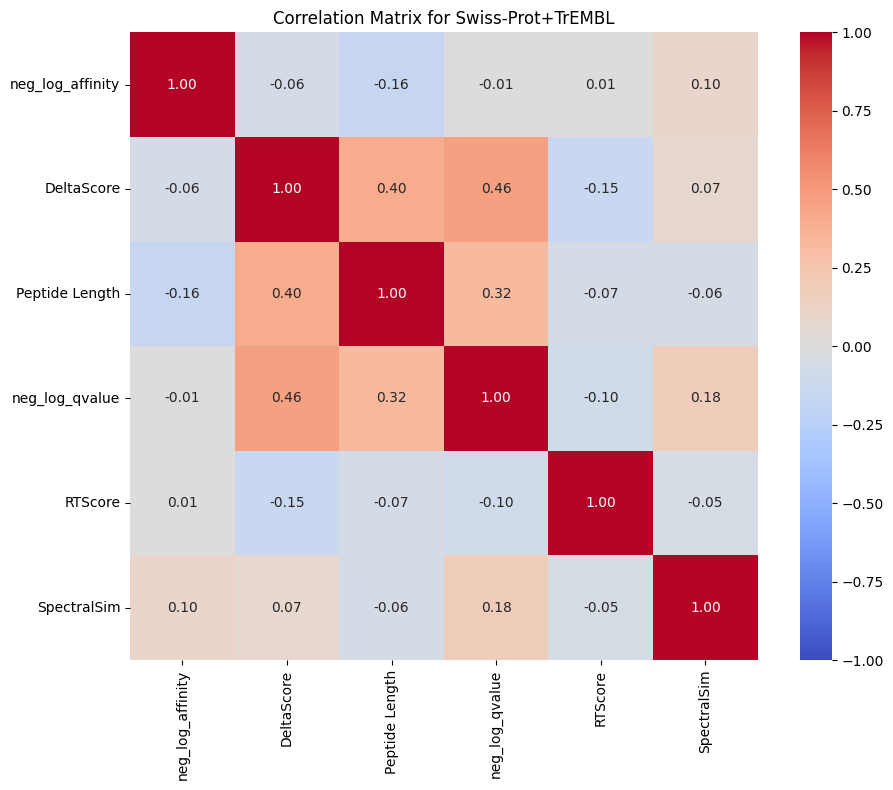

In [ ]:
list_of_metrics = ['neg_log_affinity', 'DeltaScore', 'Peptide Length', 'neg_log_qvalue', 'RTScore', 'SpectralSim']
corr = merged_df_group1[list_of_metrics].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix for Swiss-Prot+TrEMBL')
plt.tight_layout()
plt.show()

In [ ]:
predictor =  Class1PresentationPredictor.load()

alleles = [
    "HLA-A*01:01",   
    "HLA-A*03:01",
    "HLA-B*07:02",
    "HLA-B*27:05",]

affinity_group2_df = predictor.predict(peptides=list(group2_df['Peptide']), alleles=alleles)

Predicting processing.


100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


Predicting affinities.


100%|██████████| 4/4 [00:00<00:00, 16.48it/s]


In [12]:
merged_df_group2 = group2_df.merge(
    affinity_group2_df[['peptide', 'affinity']], 
    left_on='Peptide',
    right_on='peptide', 
    how='inner'
)

In [13]:
qval_group2 = merged_df_group2['Qvalue']
min_nonzero_group2 = qval_group2[qval_group2 > 0].min()   # find the smallest Qvalue that isn't zero
merged_df_group2['neg_log_qvalue'] = -np.log10(qval_group2.replace(0, min_nonzero))
merged_df_group2['neg_log_affinity'] = -np.log10(merged_df_group2['affinity']) 

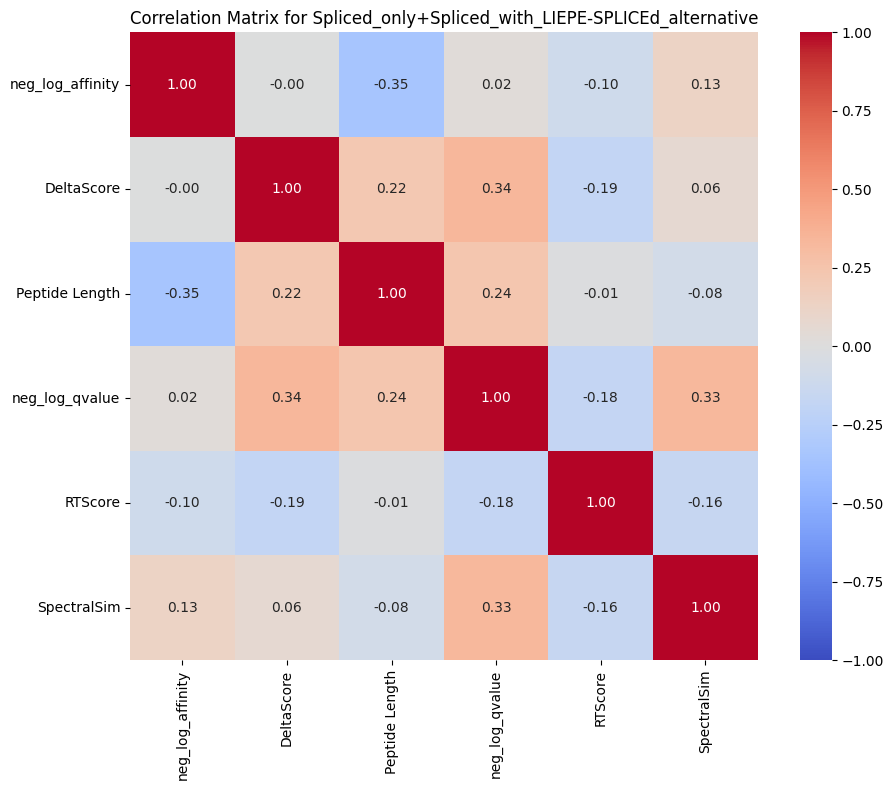

In [14]:
list_of_metrics = ['neg_log_affinity', 'DeltaScore', 'Peptide Length', 'neg_log_qvalue', 'RTScore', 'SpectralSim']
corr = merged_df_group2[list_of_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix for Spliced_only+Spliced_with_LIEPE-SPLICEd_alternative')
plt.tight_layout()
plt.show()

In [15]:
list_of_metrics = ['neg_log_affinity', 'DeltaScore', 'Peptide Length', 'neg_log_qvalue', 'RTScore', 'SpectralSim']

merged_df_group1[list_of_metrics].dropna().to_csv('group1_metrics.csv', index=False)
merged_df_group2[list_of_metrics].dropna().to_csv('group2_metrics.csv', index=False)